# 05 — Evaluation

Full evaluation on the held-out **test set** (15%).

Reports:
- Macro F1, per-class F1 (SPAM/HAM), Precision, Recall — **per language** and **overall**
- Confusion Matrix
- AUC-ROC
- Confidence calibration plot (reliability diagram)
- Assamese: separate metrics for `is_augmented=True` vs real samples
- Stratified 5-fold cross-validation on training data

> **Prerequisites**: Run notebooks 01–04 first.

In [5]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path



from src.model import load_models, predict as model_predict, MURIL_SAVE_DIR
from src.preprocess import preprocess_text, engineer_features

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110})

DATA_DIR = Path('../data')
print('Libraries loaded.')

Libraries loaded.


In [16]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score,
    classification_report, roc_curve,
)
from sklearn.calibration import calibration_curve

## 1. Load Test Data & Models

In [6]:
df_test = pd.read_csv(DATA_DIR / 'test.csv')
print(f'Test set: {len(df_test):,} rows')
print(df_test.groupby(['language', 'label']).size().unstack(fill_value=0))

# Load both model tiers
load_models()

Test set: 776 rows
label       0   1
language         
en        678  98
[inference] Loading MuRIL from c:\Users\nj465\Downloads\Spam SMS Classification\Spam SMS Classification\models\muril_finetuned


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[inference] MuRIL loaded.
[inference] LightGBM fallback available.


## 2. Generate Predictions on Test Set

In [7]:
from tqdm.auto import tqdm

def evaluate_test_set(df):
    """Run two-tier inference on the entire test set. Returns results DataFrame."""
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Evaluating'):
        text       = str(row['text'])
        lang       = str(row['language'])
        text_clean = preprocess_text(text, lang)

        feat_row = engineer_features(
            pd.DataFrame([{'text': text, 'language': lang, 'is_augmented': row.get('is_augmented', False)}])
        ).iloc[0]

        result = model_predict(
            text=text,
            text_clean=text_clean,
            language=lang,
            feature_row=feat_row,
        )

        records.append({
            'true_label':    int(row['label']),
            'pred_label':    1 if result['label'] == 'SPAM' else 0,
            'confidence':    result['confidence'],
            'tier':          result['tier'],
            'language':      lang,
            'is_augmented':  row.get('is_augmented', False),
        })

    return pd.DataFrame(records)

results_df = evaluate_test_set(df_test)
print(f'\nDone. {len(results_df)} predictions.')

Evaluating:   0%|          | 0/776 [00:00<?, ?it/s]

c:\Users\nj465\Downloads\Spam SMS Classification\Spam SMS Classification\src\model.py:438: UserWarning: MuRIL inference failed: string indices must be integers, not 'str'. Using fallback.
  warnings.warn(f"MuRIL inference failed: {e}. Using fallback.")
C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nj465\Downloads\Spam SMS Classification\Spam SMS Classification\src\model.py:438: UserWarning: MuRIL inference failed: string indices must be integers, not 'str'. Using fallback.
  warnings.warn(f"MuRIL inference failed: {e}. Using fallback.")
C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nj465\Downloads\Spam SMS Classification


Done. 776 predictions.


C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\nj465\Downloads\Spam SMS Classification\Spam SMS Classification\src\model.py:438: UserWarning: MuRIL inference failed: string indices must be integers, not 'str'. Using fallback.
  warnings.warn(f"MuRIL inference failed: {e}. Using fallback.")
C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 3. Overall Metrics

In [8]:
y_true = results_df['true_label']
y_pred = results_df['pred_label']
y_prob = results_df['confidence']

print('=== OVERALL EVALUATION ===')
print(classification_report(y_true, y_pred, target_names=['HAM', 'SPAM']))

macro_f1  = f1_score(y_true, y_pred, average='macro')
spam_auc  = roc_auc_score(y_true, y_prob)
print(f'Macro F1 : {macro_f1:.4f}')
print(f'AUC-ROC  : {spam_auc:.4f}')

=== OVERALL EVALUATION ===
              precision    recall  f1-score   support

         HAM       0.99      1.00      0.99       678
        SPAM       0.98      0.93      0.95        98

    accuracy                           0.99       776
   macro avg       0.98      0.96      0.97       776
weighted avg       0.99      0.99      0.99       776

Macro F1 : 0.9731
AUC-ROC  : 0.4545


## 4. Per-Language Metrics

In [9]:
lang_names = {'en': 'English', 'hi': 'Hindi', 'bn': 'Bengali', 'as': 'Assamese'}
rows = []

for lang in results_df['language'].unique():
    sub = results_df[results_df['language'] == lang]
    if len(sub) < 5:
        continue
    rows.append({
        'Language':  lang_names.get(lang, lang),
        'N':         len(sub),
        'Macro F1':  round(f1_score(sub.true_label, sub.pred_label, average='macro', zero_division=0), 4),
        'SPAM F1':   round(f1_score(sub.true_label, sub.pred_label, pos_label=1, zero_division=0), 4),
        'HAM F1':    round(f1_score(sub.true_label, sub.pred_label, pos_label=0, zero_division=0), 4),
        'Precision': round(precision_score(sub.true_label, sub.pred_label, average='macro', zero_division=0), 4),
        'Recall':    round(recall_score(sub.true_label, sub.pred_label, average='macro', zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(sub.true_label, sub.confidence) if sub.true_label.nunique() > 1 else float('nan'), 4),
    })

lang_metrics = pd.DataFrame(rows).set_index('Language')
print('=== PER-LANGUAGE METRICS ===')
print(lang_metrics.to_string())

=== PER-LANGUAGE METRICS ===
            N  Macro F1  SPAM F1  HAM F1  Precision  Recall  AUC-ROC
Language                                                            
English   776    0.9731   0.9529  0.9934     0.9841  0.9628   0.4545


## 5. Confusion Matrix per Language

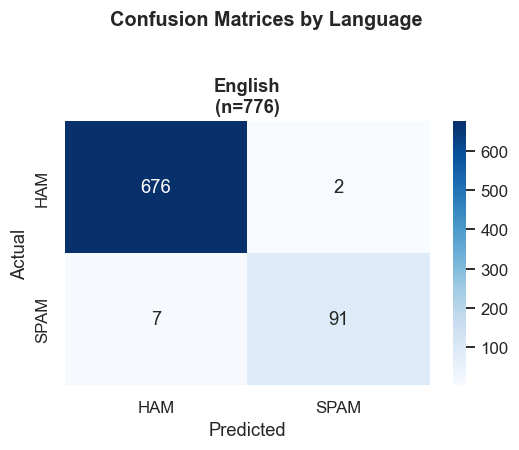

In [10]:
langs_present = [l for l in ['en', 'hi', 'bn', 'as'] if l in results_df['language'].values]
n_langs = len(langs_present)
fig, axes = plt.subplots(1, n_langs, figsize=(5 * n_langs, 4))
if n_langs == 1: axes = [axes]

for ax, lang in zip(axes, langs_present):
    sub = results_df[results_df['language'] == lang]
    cm = confusion_matrix(sub.true_label, sub.pred_label)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['HAM', 'SPAM'], yticklabels=['HAM', 'SPAM'])
    ax.set_title(f'{lang_names.get(lang, lang)}\n(n={len(sub)})', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices by Language', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../readme-resources/confusion_matrices.png', bbox_inches='tight')
plt.show()

## 6. AUC-ROC Curve

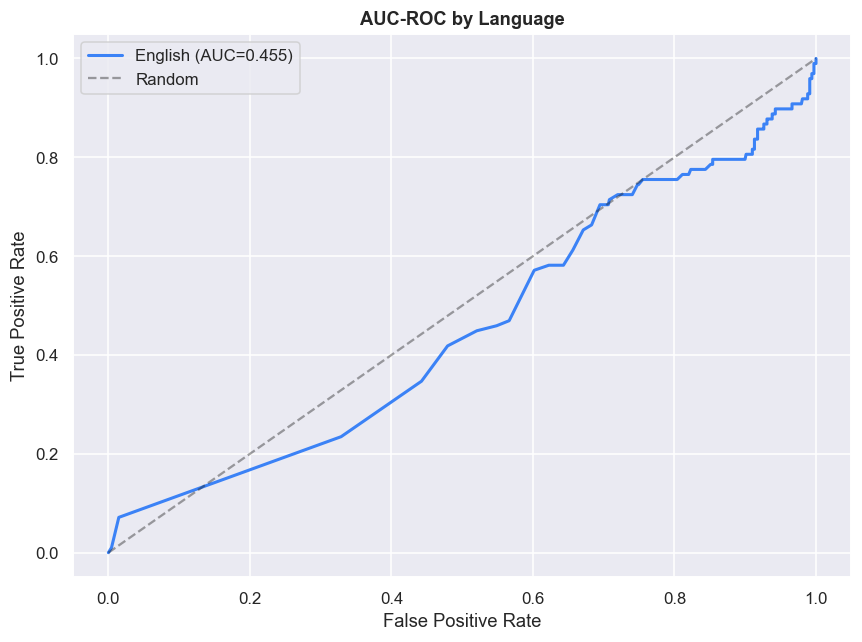

In [11]:
plt.figure(figsize=(8, 6))
colors = {'en': '#3b82f6', 'hi': '#f59e0b', 'bn': '#22c55e', 'as': '#a855f7'}

for lang in langs_present:
    sub = results_df[results_df['language'] == lang]
    if sub.true_label.nunique() < 2: continue
    fpr, tpr, _ = roc_curve(sub.true_label, sub.confidence)
    auc = roc_auc_score(sub.true_label, sub.confidence)
    plt.plot(fpr, tpr, label=f'{lang_names.get(lang, lang)} (AUC={auc:.3f})',
             color=colors.get(lang, 'grey'), linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('AUC-ROC by Language', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../readme-resources/auc_roc.png', bbox_inches='tight')
plt.show()

## 7. Confidence Calibration Plot (Reliability Diagram)

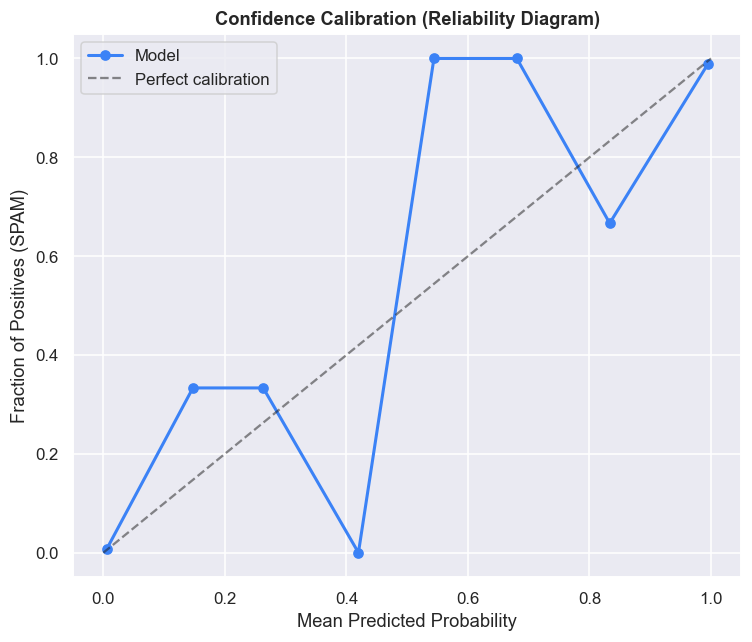

In [12]:
plt.figure(figsize=(7, 6))

# Adjust confidence to represent P(SPAM)
prob_spam = np.where(results_df['pred_label'] == 1, results_df['confidence'], 1 - results_df['confidence'])

frac_pos, mean_pred = calibration_curve(y_true, prob_spam, n_bins=10)
plt.plot(mean_pred, frac_pos, 'o-', label='Model', color='#3b82f6', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (SPAM)')
plt.title('Confidence Calibration (Reliability Diagram)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../readme-resources/calibration.png', bbox_inches='tight')
plt.show()

## 8. Assamese: Augmented vs Real Samples

In [13]:
as_results = results_df[results_df['language'] == 'as']
print(f'Assamese test samples: {len(as_results)}')

for aug_flag in [True, False]:
    sub = as_results[as_results['is_augmented'] == aug_flag]
    label = 'AUGMENTED (synthetic)' if aug_flag else 'REAL'
    if len(sub) < 2:
        print(f'{label}: too few samples ({len(sub)})')
        continue
    macro = f1_score(sub.true_label, sub.pred_label, average='macro', zero_division=0)
    print(f'\n--- {label} (n={len(sub)}) ---')
    print(f'Macro F1: {macro:.4f}')
    print(classification_report(sub.true_label, sub.pred_label,
                                target_names=['HAM', 'SPAM'], zero_division=0))

Assamese test samples: 0
AUGMENTED (synthetic): too few samples (0)
REAL: too few samples (0)


## 9. 5-Fold Cross-Validation (Training Data)

Stratified by label to give unbiased estimates.

In [19]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

df_train = pd.read_csv(DATA_DIR / 'train.csv')
if 'text_clean' not in df_train.columns:
    df_train['text_clean'] = df_train['text'].fillna('')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# ... rest of the cell
from src.model import predict_fallback

df_train = pd.read_csv(DATA_DIR / 'train.csv')
if 'text_clean' not in df_train.columns:
    df_train['text_clean'] = df_train['text'].fillna('')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print('Running 5-fold CV on Fallback (LightGBM)...')
print('(Full MuRIL CV would require re-fine-tuning 5 times — use holdout results above for Tier 1)')

for fold, (train_idx, val_idx) in enumerate(skf.split(df_train, df_train['label'])):
    from src.model import train_fallback as _train_fb
    import tempfile, pickle, scipy.sparse as sp

    fold_train = df_train.iloc[train_idx]
    fold_val   = df_train.iloc[val_idx]

    _train_fb(fold_train, df_val=fold_val)

    preds, _ = predict_fallback(
        fold_val['text_clean'].fillna('').tolist(), fold_val
    )
    fold_f1 = f1_score(fold_val['label'], preds, average='macro')
    cv_scores.append(fold_f1)
    print(f'  Fold {fold + 1}: Macro F1 = {fold_f1:.4f}')

print(f'\nFallback 5-Fold CV: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')

Running 5-fold CV on Fallback (LightGBM)...
(Full MuRIL CV would require re-fine-tuning 5 times — use holdout results above for Tier 1)
[fallback] Building TF-IDF features (char n-grams)...
[fallback] Applying SMOTE for class balance...
[fallback] Training LightGBM classifier...
[LightGBM] [Info] Number of positive: 2528, number of negative: 2528
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.075622 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 277754
[LightGBM] [Info] Number of data points in the train set: 5056, number of used features: 6169
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[100]	valid_0's binary_logloss: 0.088314
Early stopping, best iterati

C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1: Macro F1 = 0.9281
[fallback] Building TF-IDF features (char n-grams)...
[fallback] Applying SMOTE for class balance...
[fallback] Training LightGBM classifier...
[LightGBM] [Info] Number of positive: 2528, number of negative: 2528
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.068969 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 274627
[LightGBM] [Info] Number of data points in the train set: 5056, number of used features: 6261
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.0501606
Early stopping, best iteration is:
[102]	valid_0's binary_logloss: 0.0496726
[fallback] Saved TF-IDF → c:\Users\nj465\Downloads\Spam SMS Classification\Spam SMS Classification\models\fallback_tfidf.pkl
[fallbac

C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2: Macro F1 = 0.9680
[fallback] Building TF-IDF features (char n-grams)...
[fallback] Applying SMOTE for class balance...
[fallback] Training LightGBM classifier...
[LightGBM] [Info] Number of positive: 2528, number of negative: 2528
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 273985
[LightGBM] [Info] Number of data points in the train set: 5056, number of used features: 6230
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.0500975
Early stopping, best iteration is:
[110]	valid_0's binary_logloss: 0.049237
[fallback] Saved TF-IDF → c:\Users\nj465\Downloads\Spam SMS Classifica

C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 3: Macro F1 = 0.9642
[fallback] Building TF-IDF features (char n-grams)...
[fallback] Applying SMOTE for class balance...
[fallback] Training LightGBM classifier...
[LightGBM] [Info] Number of positive: 2528, number of negative: 2528
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 277217
[LightGBM] [Info] Number of data points in the train set: 5056, number of used features: 6307
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[100]	valid_0's binary_logloss: 0.0662634
Early stopping, best iteration is:
[115]	valid_0's binary_logloss: 0.06

C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 4: Macro F1 = 0.9522
[fallback] Building TF-IDF features (char n-grams)...
[fallback] Applying SMOTE for class balance...
[fallback] Training LightGBM classifier...
[LightGBM] [Info] Number of positive: 2528, number of negative: 2528
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 276772
[LightGBM] [Info] Number of data points in the train set: 5056, number of used features: 6141
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[100]	valid_0's binary_logloss: 0.0707585
Early stopping, best iteration is:
[110]	valid_0's binary_logloss: 0.0694077
[fallback] Saved TF-IDF → c:\Users\nj465\Downloads\Spam SM

C:\Users\nj465\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 10. Final Summary Table

In [20]:
print('\n' + '='*60)
print('FINAL EVALUATION SUMMARY')
print('='*60)
print(f'Overall Macro F1:  {f1_score(y_true, y_pred, average="macro"):.4f}')
print(f'SPAM F1:           {f1_score(y_true, y_pred, pos_label=1):.4f}')
print(f'HAM F1:            {f1_score(y_true, y_pred, pos_label=0):.4f}')
print(f'AUC-ROC:           {roc_auc_score(y_true, prob_spam):.4f}')
print()
print('Per-Language Macro F1:')
print(lang_metrics[['Macro F1', 'SPAM F1', 'HAM F1', 'AUC-ROC']].to_string())
print('='*60)


FINAL EVALUATION SUMMARY
Overall Macro F1:  0.9731
SPAM F1:           0.9529
HAM F1:            0.9934
AUC-ROC:           0.9925

Per-Language Macro F1:
          Macro F1  SPAM F1  HAM F1  AUC-ROC
Language                                    
English     0.9731   0.9529  0.9934   0.4545
